# 🧠 Building a Probabilistic Digital Twin: Bayesian PI-NODE-SR
Welcome to this interactive guide on upgrading the **Physics-Informed Neural ODE with Scale-Aware Residuals (PI-NODE-SR)** framework to a fully **Bayesian Probabilistic Programming** architecture.

In this notebook, we will explore the mathematical foundations of learning stiff biophysical dynamics (like the Hodgkin-Huxley equations) not by searching for a single "best" neural network, but by mapping a landscape of all physically plausible realities.

---

## 1. The Core Problem: Stiff Biophysical Dynamics
Biological systems are notoriously difficult for standard Neural ODEs to learn because they are **stiff**. Stiffness arises when different variables in a system evolve on vastly disparate timescales[cite: 1].

### The Hodgkin-Huxley (HH) Example
Consider the HH model, which governs the nonlinear dynamics of a neuronal membrane:
*   **Fast Variable:** The membrane voltage ($V$) spikes incredibly quickly in a matter of milliseconds.
*   **Slow Variables:** The ion channel gating recovery variables ($n, m, h$) evolve much more slowly and within a strictly bounded domain (0 to 1)[cite: 1].

When standard machine learning models try to fit this data, they suffer from **numerical diffusion and gradient pathologies**. They tend to overfit to the massive spikes of the voltage variable while completely ignoring the slow, tiny gradients of the gating variables. As a result, standard Neural ODEs fail to generalize, drifting in phase and eventually collapsing to non-spiking subthreshold states[cite: 1].

## 2. The Deterministic Solution: PI-NODE-SR
To fix this gradient imbalance, the PI-NODE-SR framework introduces two critical innovations:

1.  **Scale-Aware Residuals:** Instead of treating all physics equations equally, the physics loss is normalized by a scaling factor $s_{j}$ (traditionally the empirical standard deviation of the derivative)[cite: 1].
2.  **Solver-Loss Synergy:** By balancing the residuals, the model can surprisingly utilize a low-order explicit solver like **Heun's method**, which is typically highly unstable for stiff systems, to accurately extrapolate long-horizon dynamics[cite: 1].

### The Deterministic Loss Function
The deterministic model minimizes a composite loss function:
$$ \mathcal{L}_{total} = \mathcal{L}_{data} + \lambda \mathcal{L}_{physics} $$

Where the physics loss is defined as:
$$ \mathcal{L}_{physics} = \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{4} \left( \frac{r_{ij}}{s_{j}} \right)^{2} $$
*Here, $r_{ij}$ is the residual error of the physics equation, $s_{j}$ is the fixed scaling factor, and $\lambda$ is a fixed hyperparameter balancing the two objectives[cite: 1].*

## 3. Why Upgrade to a Bayesian Framework?
While the deterministic PI-NODE-SR achieves stable long-term extrapolation[cite: 1], it suffers from significant limitations that a Bayesian framework elegantly solves:

*   **Initialization Sensitivity:** The model is highly sensitive to how the neural network weights are initialized, occasionally getting stuck in local minima where the neuron fails to spike[cite: 1].
*   **Manual Tuning:** The scale factors ($s_{j}$) and the physics weight ($\lambda$) must be manually calculated and tuned by the researcher.
*   **No Uncertainty Quantification (UQ):** The model predicts a single trajectory. If the model starts to drift after 100 milliseconds, it gives the researcher no mathematical warning.

### The Bayesian Paradigm Shift
Instead of using optimizers like Adam to find a single point-estimate of the network weights ($\theta$), we will use **Markov Chain Monte Carlo (MCMC)** to find the **Posterior Distribution** of the weights, scales, and hyperparameters. We shift from answering *"What is the equation?"* to answering *"Given the data and the physics, what is the probability distribution of all possible equations?"*

## 4. Defining the Generative Model (The Priors)
In a probabilistic programming framework (like Turing.jl or Pyro), we first define our **Priors**—our mathematical beliefs about the system before we observe any data.

By turning manual hyperparameters into latent random variables, we allow the system to self-regulate.

1.  **The Neural Network Weights ($\theta$):**
    We assume the weights are normally distributed around zero. This acts as equivalent to L2 regularization in classical ML.
    $$ \theta \sim \mathcal{N}(0, \alpha I) $$
2.  **The Scale-Aware Parameters ($s_{j}$):**
    Instead of calculating $s_j$ manually, we assign it a **Half-Cauchy** prior. The Cauchy distribution has heavy tails, which allows the model to dynamically "stretch" the scale if it discovers that a specific variable (like the $m$-gate) is excessively stiff.
    $$ s_{j} \sim \text{Half-Cauchy}(\gamma) \quad \text{for } j \in \{V, n, m, h\} $$
3.  **The Physics Weight ($\lambda$):**
    We treat the balance between data and physics as a random variable governed by a Gamma distribution, ensuring it stays strictly positive.
    $$ \lambda \sim \text{Gamma}(a, b) $$
4.  **Observation Noise ($\sigma_{obs}$):**
    We estimate the inherent biological "jitter" in the data.
    $$ \sigma_{obs} \sim \text{Normal}_{+}(0, \sigma) $$

## 5. The Two-Headed Likelihood Function
To train a Bayesian model, we convert classical loss functions (Mean Squared Error) into **Log-Likelihoods**. We establish two "observation" pathways: one for the empirical data, and one for the physical laws.

### A. The Data Likelihood (Measurement Model)
We state that the noisy biological observations $\tilde{z}(t)$ follow a Normal distribution centered perfectly on the trajectory predicted by our Neural ODE:

$$ p(\mathcal{D} \mid \theta, \sigma_{obs}) = \prod_{i=1}^{N} \mathcal{N} \left( \tilde{z}_{i} \mid \text{ODESolve}(f_{\theta}, z_{0}, t_{i}), \sigma_{obs}^{2} \right) $$

### B. The Physics Likelihood (Virtual Observation)
This is the probabilistic upgrade of the scale-aware residual constraint. We treat the physical Hodgkin-Huxley equations as **virtual observations**. We tell the model: *"We observe that the physics residual $r_{ij}$ must be exactly 0, but we allow a variance defined by our learned scales $s_{j}$."*

$$ p(f_{phys} \mid \theta, s_{j}, \lambda) = \prod_{i=1}^{N} \prod_{j=1}^{4} \mathcal{N} \left( r_{ij} \mid 0, \frac{s_{j}^{2}}{\lambda} \right) $$

> **💡 The Magic of Automatic Relevance Determination (ARD):** 
> If the physics equation for the voltage $V$ is highly mismatched, the residual $r_{iV}$ will be large. To maximize the log-likelihood without breaking the data fit, the Bayesian sampler will automatically push the latent variable $s_{V}$ higher, widening the distribution and dynamically reducing the penalty for that specific stiffness!

## 6. Inference and the Adjoint Method
To explore this highly complex, high-dimensional probability space, we use the **No-U-Turn Sampler (NUTS)**, a highly efficient gradient-based MCMC algorithm.

### The Stiff Gradient Problem
Because NUTS relies on gradients to navigate the probability landscape, we must compute the gradient of the Neural ODE output with respect to its parameters. 

The choice of gradient calculation is critical. As noted in the PI-NODE-SR framework, using standard "backsolve" adjoint methods on stiff spike dynamics results in exploding or vanishing sensitivities, causing the training to collapse entirely[cite: 1]. 

To survive the mathematical violence of a neuronal spike, the Bayesian inference engine must be paired with an **Interpolating Adjoint**. This provides a smooth, spline-based trajectory for backpropagation, allowing the sampler to maintain stable supervision through sharp, stiff transients[cite: 1].

## 7. The Final Product: Uncertainty-Aware Physics
Once the NUTS sampler finishes running, we are left with a posterior distribution of thousands of highly probable parameter sets.

What do we gain from this?

1.  **Confidence Ribbons:** Instead of projecting a single deterministic voltage trace into the future, we draw 100 trajectories from our posterior. As we extrapolate beyond the training window (e.g., past 100ms), the lines will begin to fan out. This visual ribbon tells us exactly *when* the model's physical confidence breaks down.
2.  **Physics Discovery:** By plotting the posterior distributions of the $s_{j}$ scale variables, we can perform structural diagnostics. If $s_m$ has a vastly wider distribution than $s_n$, the model is mathematically proving to us that the sodium activation gate is the primary source of biological stiffness.
3.  **Robustness:** Because MCMC explores the entire loss landscape rather than greedily falling into the nearest local minimum, it entirely circumvents the initialization sensitivity that plagues deterministic PI-NODEs[cite: 1].

*We have successfully upgraded a curve-fitter into a Probabilistic Digital Twin that reasons about its own uncertainty.*

In [22]:
# import Pkg; Pkg.add(["Turing", "Distributions", "LinearAlgebra", "Lux", "DifferentialEquations", "SciMLSensitivity", "Statistics", "DataFrames", "Plots", "Random", "ComponentArrays"])


In [7]:
using Base.Threads
println("Currently using $(Threads.nthreads()) threads")
using LinearAlgebra

Currently using 1 threads


In [8]:


# Set BLAS to use your physical cores (Try 10 first, then 20)
BLAS.set_num_threads(10) 
println("BLAS using $(BLAS.get_num_threads()) threads")

BLAS using 10 threads


In [9]:
using Turing, Distributions, DifferentialEquations
using Lux, SciMLSensitivity, ComponentArrays, Random


In [10]:
using CSV
using DataFrames

# 1. Define the file path
file_path = raw"E:\Neural_Spiking_Dynamics\notebooks\1_data_generation\single_spike_noisy_data.csv"


"E:\\Neural_Spiking_Dynamics\\notebooks\\1_data_generation\\single_spike_noisy_data.csv"

In [11]:

# 2. Read the CSV directly into a DataFrame (Raw Order: timestamp, V, m, n, h)
HH_data_raw = CSV.read(file_path, DataFrame)

# 3. Select all rows (:) and reorder the columns as desired
df_ordered = HH_data_raw[:, [:timestamp, :V, :n, :m, :h]]

# Display the first few rows to verify the new order
first(df_ordered, 5)
          

Row,timestamp,V,n,m,h
,Float64,Float64,Float64,Float64,Float64
1,0.0,-65.0,0.6,0.05,0.32
2,0.01,-64.8362,0.599784,0.0502886,0.320059
3,0.02,-64.7979,0.599864,0.050523,0.32014
4,0.03,-64.7164,0.599507,0.0507588,0.319583
5,0.04,-64.6138,0.599157,0.0510483,0.319957


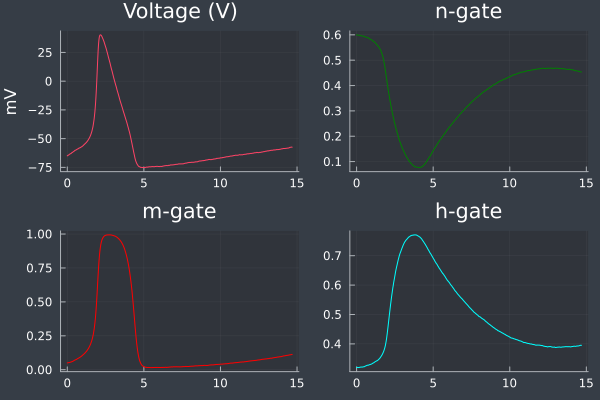

In [12]:
HH_data=HH_data_raw
using Plots
theme(:dark)
# Create 4 subplots in a 2x2 grid
p1 = plot(df_ordered.timestamp, df_ordered.V, title="Voltage (V)", ylabel="mV")
p2 = plot(df_ordered.timestamp, df_ordered.n, title="n-gate", color=:green)
p3 = plot(df_ordered.timestamp, df_ordered.m, title="m-gate", color=:red)
p4 = plot(df_ordered.timestamp, df_ordered.h, title="h-gate", color=:cyan)

plot(p1, p2, p3, p4, layout=(2, 2), legend=false)


In [13]:
# %%
df_ordered = HH_data[:, [:timestamp, :V, :n, :m, :h]]

# %%
t_train = Float32.(df_ordered.timestamp)
z_train = Float32.(Matrix(df_ordered[:, [:V, :n, :m, :h]])')

4×1469 Matrix{Float32}:
 -65.0   -64.8363     -64.7979    …  -57.3823    -57.4143    -57.4497
   0.6     0.599784     0.599864       0.453623    0.453502    0.453245
   0.05    0.0502886    0.050523       0.112056    0.112553    0.112654
   0.32    0.320059     0.32014        0.395085    0.395061    0.39517

### Definging the HH equations


In [14]:

# 1. Biological constants for the Hodgkin-Huxley model
const C_m = 1.0     # Membrane capacitance (uF/cm^2)
const g_Na = 120.0  # Maximum sodium conductance (mS/cm^2)
const g_K = 36.0    # Maximum potassium conductance (mS/cm^2)
const g_L = 0.3     # Maximum leak conductance (mS/cm^2)
const E_Na = 50.0   # Sodium reversal potential (mV)
const E_K = -77.0   # Potassium reversal potential (mV)
const E_L = -54.387 # Leak reversal potential (mV)

# 2. Rate functions for gating variables (how fast channels open/close based on voltage)
α_n(v) = 0.01 * (v + 55.0) / (1.0 - exp(-0.1 * (v + 55.0)))
β_n(v) = 0.125 * exp(-0.0125 * (v + 65.0))

α_m(v) = 0.1 * (v + 40.0) / (1.0 - exp(-0.1 * (v + 40.0)))
β_m(v) = 4.0 * exp(-0.05 * (v + 65.0))

α_h(v) = 0.07 * exp(-0.05 * (v + 65.0))
β_h(v) = 1.0 / (1.0 + exp(-0.1 * (v + 35.0)))

# 3. The Hodgkin-Huxley ODE system
function hodgkin_huxley_equations!(du, u, p, t)
    v, n, m, h = u
    I_ext = p  # External injected current (our stimulus)

    # Voltage equation: How the electrical potential changes
    du[1] = (I_ext - g_Na * (m^3) * h * (v - E_Na) - g_K * (n^4) * (v - E_K) - g_L * (v - E_L)) / C_m

    # Gating variables equations: How the ion channels open/close
    du[2] = α_n(v) * (1 - n) - β_n(v) * n
    du[3] = α_m(v) * (1 - m) - β_m(v) * m
    du[4] = α_h(v) * (1 - h) - β_h(v) * h
end

hodgkin_huxley_equations! (generic function with 1 method)

In [15]:
u0_true = z_train[:, 1]

4-element Vector{Float32}:
 -65.0
   0.6
   0.05
   0.32

In [16]:
tspan = (t_train[1], t_train[end])

(0.0f0, 14.68f0)

In [17]:
p_true = 10.0

10.0

In [18]:
# define the problem 
prob_true = ODEProblem(hodgkin_huxley_equations!, u0_true, tspan, p_true)
sol_true = solve(prob_true, Rodas5P(), saveat=t_train)

retcode: Success
Interpolation: 1st order linear
t: 1469-element Vector{Float32}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  0.1
  0.11
  0.12
  ⋮
 14.57
 14.58
 14.59
 14.6
 14.61
 14.62
 14.63
 14.64
 14.65
 14.66
 14.67
 14.68
u: 1469-element Vector{Vector{Float32}}:
 [-65.0, 0.6, 0.05, 0.32]
 [-65.41124, 0.5994786, 0.050070945, 0.320332]
 [-65.80074, 0.59894896, 0.050042905, 0.32067886]
 [-66.16969, 0.59841174, 0.04992568, 0.32103983]
 [-66.5192, 0.5978674, 0.049728483, 0.3214141]
 [-66.85034, 0.5973166, 0.049459904, 0.32180095]
 [-67.16409, 0.5967597, 0.049127936, 0.32219967]
 [-67.46138, 0.596197, 0.04873999, 0.32260966]
 [-67.74312, 0.59562904, 0.048303124, 0.32303026]
 [-68.01012, 0.5950561, 0.047823712, 0.32346097]
 [-68.26317, 0.59447867, 0.0473077, 0.3239012]
 [-68.50303, 0.5938969, 0.0467606, 0.32435045]
 [-68.73037, 0.5933112, 0.0461875, 0.32480824]
 ⋮
 [-74.37216, 0.6296669, 0.017401008, 0.1924929]
 [-74.36075, 0.62890357, 0.017411407, 0.193358

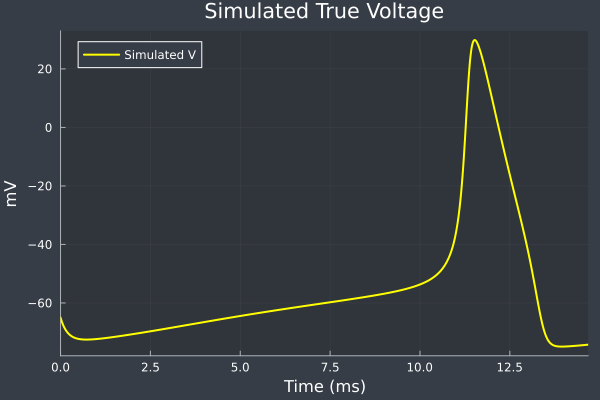

In [19]:
plot(sol_true, idxs=1, title="Simulated True Voltage", label="Simulated V", ylabel="mV", xlabel="Time (ms)", color=:yellow, linewidth=2)

### Neural Architecture

In [20]:
nn = Chain(Dense(5 => 32, tanh),
          Dense(32 => 32, tanh),
          Dense(32 =>4 )
          )

# Initializing the Weights and parameters with  random valuse



Chain(
    layer_1 = Dense(5 => 32, tanh),               # 192 parameters
    layer_2 = Dense(32 => 32, tanh),              # 1_056 parameters
    layer_3 = Dense(32 => 4),                     # 132 parameters
)         # Total: 1_380 parameters,
          #        plus 0 states.

In [21]:
rng = Random.default_rng()
Random.seed!(rng, 123)

p_nn, st_nn = Lux.setup(rng, nn)


((layer_1 = (weight = Float32[-1.2605429 -1.2377222 … -0.108152345 0.003740042; 1.049061 0.7077016 … 0.025925437 -1.0559225; … ; -0.93651116 0.2284065 … -1.1917123 -0.7900761; 1.1862524 0.5448991 … -1.2125566 0.025036057], bias = Float32[-0.07871951, 0.37492698, -0.32566726, -0.06617045, 0.0045949095, 0.22055346, -0.4445852, 0.2855019, 0.018314436, 0.4062124  …  -0.06524479, 0.27207884, -0.33715045, -0.33671778, -0.026043667, 0.21468061, 0.12711616, 0.18402599, 0.29434794, 0.4400231]), layer_2 = (weight = Float32[-0.33729726 -0.2967689 … 0.26706392 0.0657999; 0.17880732 0.39956307 … -0.04604268 -0.44283146; … ; -0.1698411 0.2567483 … -0.09241204 0.4760831; -0.09733203 0.2853362 … 0.12108438 0.010632642], bias = Float32[-0.1722957, -0.082803324, -0.14402696, 0.058591813, 0.06362286, 0.11863828, 0.06275699, -0.05730176, 0.13999988, 0.033415664  …  0.0652428, -0.025979318, 0.09058333, -0.10704244, -0.13244265, 0.06129648, -0.008535011, 0.10064598, -0.009298058, 0.122323535]), layer_3 = (w

In [22]:
using Optimisers # Provides the destructure function

# p_nn_flat is a 1D vector. 
# restructure_fn is a tool to rebuild the NamedTuple later!
p_nn_flat, restructure_fn = destructure(p_nn) 
p_flat_length = length(p_nn_flat)


1380

In [34]:
# Physics Wrapper: Converts in-place mutation to a returning function

function get_true_physics_derivatives(u, I_ext)
    # 1. Create an empty array of the exact same type/size as 'u'
    # Using similar(u) is CRITICAL here so Turing's automatic differentiation doesn't crash.
    du = similar(u) 
    
    # 2. Call the original Hodgkin-Huxley function we defined in Cell 1.
    # The signature is: hodgkin_huxley!(du, u, p, t)
    # 'p' is our injected current (I_ext). Time 't' is 0.0 since standard HH rates don't depend on absolute time.
    hodgkin_huxley_equations!(du, u, I_ext, 0.0)
    
    # 3. Return the calculated derivatives to the Turing model
    return du
end

get_true_physics_derivatives (generic function with 1 method)

### Digital twin of bayesian model here

In [35]:
# FIX 5: Added 'nn' to the function arguments
@model function bayesian_pinode(data_z, t_steps, prob_base, p_flat_length, restructure_fn, st_nn, nn)
    
    ## Our priors
    # FIX 2: Removed p_len entirely.
    theta ~ MvNormal(zeros(p_flat_length), I)
    
    # Rebuild the flat 'theta' back into Lux's NamedTuple format
    theta_structured = restructure_fn(theta)

    # Defining the dynamics of stiff SYSTEM
    s_V ~ truncated(Cauchy(0.0, 10.0), 0.0, Inf)
    s_n ~ truncated(Cauchy(0.0, 1.0), 0.0, Inf)
    s_m ~ truncated(Cauchy(0.0, 1.0), 0.0, Inf)
    s_h ~ truncated(Cauchy(0.0, 1.0), 0.0, Inf)
    scales = [s_V, s_n, s_m, s_h]
    
    # Physics Weight and Observation Noise
    lambda ~ Gamma(2.0, 1.0)
    sigma_obs ~ truncated(Normal(0.0, 0.5), 0.0, Inf)
    
    # Redefine the problem
    # FIX 1: Changed 'prob' to 'prob_base'
    new_prob = remake(prob_base, p=theta)

    # FIX 3: Changed 'prob_sol' to 'pred_sol'
    pred_sol = solve(new_prob, Heun(), saveat = t_steps, sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))
    
    if pred_sol.retcode != ReturnCode.Success
        Turing.@addlogprob! -Inf
        return nothing
    end

    pred_z = Array(pred_sol)

    # THE LIKELIHOOD SYSTEM
    for i in 1:size(data_z, 2)
        for j in 1:4
            # FIX 4: Changed 'pred_z[j.i]' to 'pred_z[j, i]'
            data_z[j, i] ~ Normal(pred_z[j, i], sigma_obs)
        end
    end
    
    # SCORE 2: The Physics Likelihood (Does the simulation obey biology?)
    for i in 1:size(pred_z, 2)
        u_t = pred_z[:, i]
        t = t_steps[i]
    
        du_nn, _ = nn(vcat(u_t, [t]), theta_structured, st_nn)
        du_phys = get_true_physics_derivatives(u_t, 10.0) 
        residuals = du_nn .- du_phys
        
        for j in 1:4
            Turing.@addlogprob! logpdf(Normal(0.0, scales[j] / sqrt(lambda)), residuals[j])
        end
        
    end 
end 


bayesian_pinode (generic function with 2 methods)

In [36]:
function nn_ode!(du, u, p, t)
    # Rebuild the structured parameters from the flat vector 'p'
    p_struct = restructure_fn(p)
    du_nn, _ = nn(vcat(u, [t]), p_struct, st_nn)
    du .= du_nn
end

nn_ode! (generic function with 1 method)

In [37]:
# Define the base problem using our initial conditions and timestamps
prob_base = ODEProblem(nn_ode!, z_train[:, 1], (t_train[1], t_train[end]), p_nn_flat)

ODEProblem with uType Vector{Float32} and tType Float32. In-place: true
Non-trivial mass matrix: false
timespan: (0.0f0, 14.68f0)
u0: 4-element Vector{Float32}:
 -65.0
   0.6
   0.05
   0.32

In [ ]:

# 4. Instantiate the model with ALL 7 arguments!
model_instance = bayesian_pinode(
    z_train,          # Lab data
    t_train,          # Timestamps
    prob_base,        # The Neural ODE blueprint
    p_flat_length,    # How many weights to sample
    restructure_fn,   # The tool to rebuild the weights
    st_nn,            # The internal network state
    nn                # The Lux network architecture
)
# 5. Run the Sampler
println("The Bayesian Detective is now exploring the probability landscape...")
chain = sample(
    model_instance, 
    NUTS(0.65), 
    MCMCThreads(),    # Enables multithreading
    100,              # Number of samples per chain
    4,                # Number of chains to run (matches your 4 Julia threads)
    progress=true     # Shows the progress bar
)

The Bayesian Detective is now exploring the probability landscape...


┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC C:\Users\nirbh\.julia\packages\AbstractMCMC\C1aKp\src\sample.jl:544


In [ ]:
Threads.nthreads()

1